# Problem 3 — Polynomial Regression
# 🚗 Predict Car Price from Age

# This problem introduces a non-linear relationship.

## Problem Statement

## A used-car company wants to predict the price of a car based on its age.

## The relationship isn't necessarily a straight line. A new car can lose value rapidly in its first few years, with depreciation changing over time.

In [7]:
# import importn libery 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import  warnings
warnings.filterwarnings("ignore")



In [9]:
data = {
    "age": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "price": [18, 16, 14, 12, 10.5,
              9, 7.8, 7, 6.5, 6]
}

df = pd.DataFrame(data)

# Step 1 — Visualize

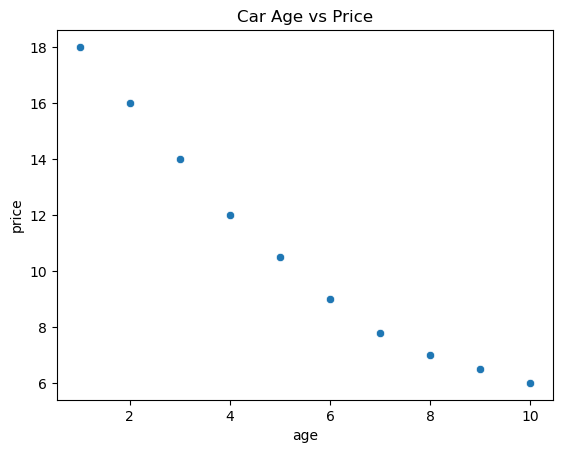

In [12]:
sns.scatterplot(
    x="age",
    y="price",
    data=df
)

plt.title("Car Age vs Price")

plt.show()

# Step 2 — Create X and y

In [15]:
X = df[["age"]]

y = df["price"]

# Step 3 — Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 4 — Polynomial Features

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2
)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

# Step 5 — Train

In [24]:
model = LinearRegression()

model.fit(
    X_train_poly,
    y_train
)

LinearRegression()

# Step 6 — Prediction

In [27]:
y_pred = model.predict(
    X_test_poly
)

# Step 7 — Evaluate

In [30]:
print(
    "MAE:",
    mean_absolute_error(y_test, y_pred)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )
)

print(
    "R2:",
    r2_score(y_test, y_pred)
)

MAE: 0.14385245901639365
RMSE: 0.1441936658066555
R2: 0.9990784791907474


# Step 8 — Visualize Polynomial Regression

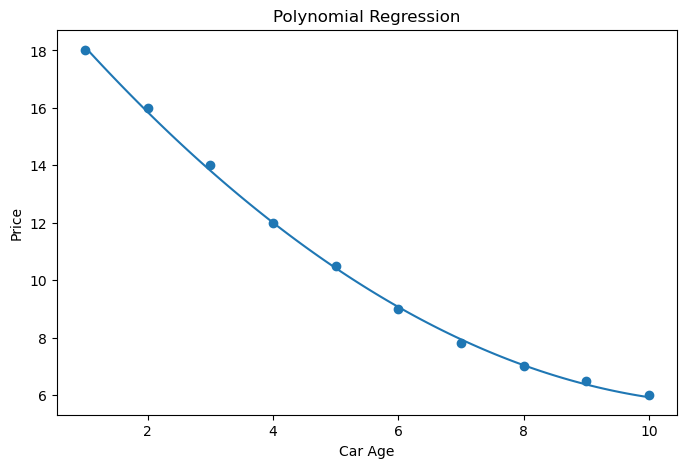

In [35]:
import numpy as np

X_curve = np.linspace(
    X.min(),
    X.max(),
    100
).reshape(-1, 1)

X_curve_poly = poly.transform(
    X_curve
)

y_curve = model.predict(
    X_curve_poly
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y
)

plt.plot(
    X_curve,
    y_curve
)

plt.xlabel("Car Age")
plt.ylabel("Price")
plt.title("Polynomial Regression")

plt.show()

In [37]:
degree=1

In [39]:
degree=2

In [41]:
degree=3

In [43]:
degree=5

In [45]:
# Compare the results.

# This will help you understand underfitting and overfitting.